# Bitcoin Price Prediction using Linear, Ridge, and Lasso Regression

This project compares three regression algorithms for predicting the next-day Bitcoin closing price:

- Linear Regression
- Ridge Regression
- Lasso Regression

Historical Bitcoin market data is used along with time-series feature engineering.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.linear_model import LinearRegression , Lasso , Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error , mean_absolute_error , root_mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
btc=yf.download("BTC-USD" , start="2020-01-01" , auto_adjust=False)
btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,,
2020-01-01,7200.174316,7200.174316,7254.330566,7174.944336,7194.892090,18565664997
2020-01-02,6985.470215,6985.470215,7212.155273,6935.270020,7202.551270,20802083465
2020-01-03,7344.884277,7344.884277,7413.715332,6914.996094,6984.428711,28111481032
2020-01-04,7410.656738,7410.656738,7427.385742,7309.514160,7345.375488,18444271275
2020-01-05,7411.317383,7411.317383,7544.497070,7400.535645,7410.451660,19725074095


In [3]:
print(btc.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2433 entries, 2020-01-01 to 2026-08-30
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   (Adj Close, BTC-USD)  2433 non-null   float64
 1   (Close, BTC-USD)      2433 non-null   float64
 2   (High, BTC-USD)       2433 non-null   float64
 3   (Low, BTC-USD)        2433 non-null   float64
 4   (Open, BTC-USD)       2433 non-null   float64
 5   (Volume, BTC-USD)     2433 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 133.1 KB
None


In [7]:
btc.columns=btc.columns.droplevel(1)
btc=btc[["Open","High","Low","Close","Volume"]]


In [8]:
btc.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2020-01-01,7194.892090,7254.330566,7174.944336,7200.174316,18565664997
2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215,20802083465
2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277,28111481032
2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738,18444271275
2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383,19725074095


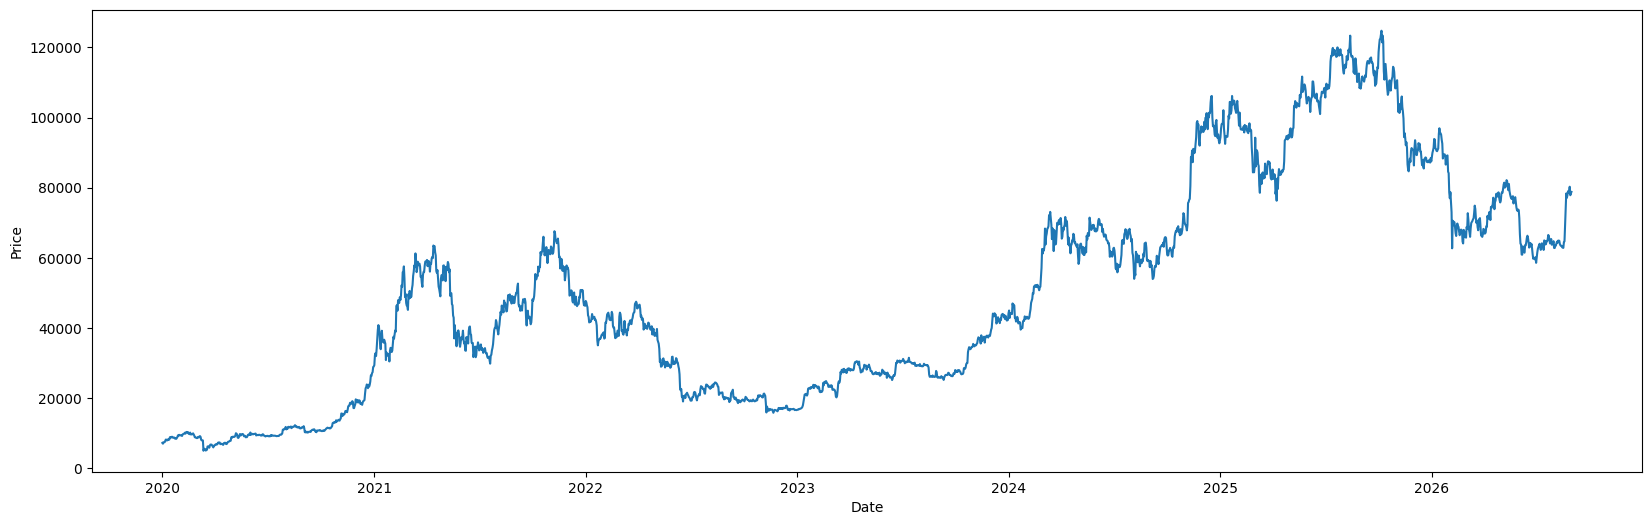

In [10]:
fig=plt.figure(figsize=(20,6))
plt.plot(btc.index , btc['Close'])
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [19]:
df=btc.copy()
df["Previous_Close"]=df["Close"].shift(1)
df["Return_1D"]=df["Close"].pct_change()
df["MA_7"]=df["Close"].rolling(7).mean()
df["MA_30"]=df["Close"].rolling(30).mean()
df["Volatility_7"]=df["Return_1D"].rolling(7).std()
df["High_Low_Range"]=df["High"]-df["Low"]
df["Open_Close_Diff"]=df["Open"]-df["Close"]

In [20]:
df.head(10)

Price,Open,High,Low,Close,Volume,Previous_Close,Return_1D,MA_7,MA_30,Volatility_7,High_Low_Range,Open_Close_Diff
Date,,,,,,,,,,,,
2020-01-01,7194.892090,7254.330566,7174.944336,7200.174316,18565664997,NaN,NaN,NaN,NaN,NaN,79.386230,-5.282227
2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215,20802083465,7200.174316,-0.029819,NaN,NaN,NaN,276.885254,217.081055
2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277,28111481032,6985.470215,0.051452,NaN,NaN,NaN,498.719238,-360.455566
2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738,18444271275,7344.884277,0.008955,NaN,NaN,NaN,117.871582,-65.281250
2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383,19725074095,7410.656738,0.000089,NaN,NaN,NaN,143.961426,-0.865723
2020-01-06,7410.452148,7781.867188,7409.292969,7769.219238,23276261598,7411.317383,0.048291,NaN,NaN,NaN,372.574219,-358.767090
2020-01-07,7768.682129,8178.215820,7768.227539,8163.692383,28767291327,7769.219238,0.050774,7469.344936,NaN,NaN,409.988281,-395.010254
2020-01-08,8161.935547,8396.738281,7956.774414,8079.862793,31672559265,8163.692383,-0.010269,7595.014718,NaN,0.033149,439.963867,82.072754
2020-01-09,8082.295898,8082.295898,7842.403809,7879.071289,24045990466,8079.862793,-0.024851,7722.672015,NaN,0.032011,239.892090,203.224609


In [21]:
df["Target"]=df["Close"].shift(-1)

In [22]:
df.dropna(inplace=True)
df.head(10)

Price,Open,High,Low,Close,Volume,Previous_Close,Return_1D,MA_7,MA_30,Volatility_7,High_Low_Range,Open_Close_Diff,Target
Date,,,,,,,,,,,,,
2020-01-30,9316.016602,9553.125977,9230.897461,9508.993164,32378792851,9316.629883,0.020647,8929.163504,8357.228516,0.022002,322.228516,-192.976562,9350.529297
2020-01-31,9508.313477,9521.706055,9230.776367,9350.529297,29432489719,9508.993164,-0.016665,9058.462751,8428.907015,0.025368,290.929688,157.784180,9392.875000
2020-02-01,9346.357422,9439.323242,9313.239258,9392.875000,25922656496,9350.529297,0.004529,9204.895229,8509.153841,0.023668,126.083984,-46.517578,9344.365234
2020-02-02,9389.820312,9468.797852,9217.824219,9344.365234,30835736946,9392.875000,-0.005165,9311.685965,8575.803206,0.024447,250.973633,45.455078,9293.521484
2020-02-03,9344.683594,9540.372070,9248.633789,9293.521484,30934096509,9344.365234,-0.005441,9366.500558,8638.565365,0.022598,291.738281,51.162109,9180.962891
2020-02-04,9292.841797,9331.265625,9112.811523,9180.962891,29893183716,9293.521484,-0.012112,9341.125279,8697.553548,0.012232,218.454102,111.878906,9613.423828
2020-02-05,9183.416016,9701.299805,9163.704102,9613.423828,35222060874,9180.962891,0.047104,9383.524414,8759.027035,0.022330,537.595703,-430.007812,9729.801758
2020-02-06,9617.821289,9824.619141,9539.818359,9729.801758,37628823716,9613.423828,0.012106,9415.068499,8811.230680,0.021532,284.800781,-111.980469,9795.943359
2020-02-07,9726.002930,9834.716797,9726.002930,9795.943359,34522718159,9729.801758,0.006798,9478.699079,8868.433366,0.019614,108.713867,-69.940430,9865.119141


In [23]:
features = [
    "Open",
    "High",
    "Low",
    "Volume",
    "Previous_Close",
    "Return_1D",
    "MA_7",
    "MA_30",
    "Volatility_7",
    "High_Low_Range",
    "Open_Close_Diff"
]

X = df[features]
y = df["Target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2403, 11)
y shape: (2403,)


In [25]:
X_train , X_test , y_train , y_test = train_test_split(X, y, train_size=0.8,shuffle=False, random_state=42)

In [27]:
print("Training samples:" , len(X_train) )
print ("Test samples:" , len(X_test) )

Training samples: 1922
Test samples: 481


In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred=linear_model.predict(X_test_scaled)

In [30]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred=ridge_model.predict(X_test_scaled)

In [36]:
lasso_model = Lasso(alpha=0.1 , max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred=lasso_model.predict(X_test_scaled)

C:\Users\Kiana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.067e+08, tolerance: 1.152e+08
  model = cd_fast.enet_coordinate_descent(


In [39]:
def evaluate_model(name , y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "MSE": mse,
    }

In [40]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_pred
    )
)

results.append(
    evaluate_model(
        "Ridge Regression",
        y_test,
        ridge_pred
    )
)

results.append(
    evaluate_model(
        "Lasso Regression",
        y_test,
        lasso_pred
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,MSE
0,Linear Regression,1345.458234,1876.867867,3.522633e+06
1,Ridge Regression,1341.855546,1876.905908,3.522776e+06
2,Lasso Regression,1345.175328,1876.626931,3.521729e+06


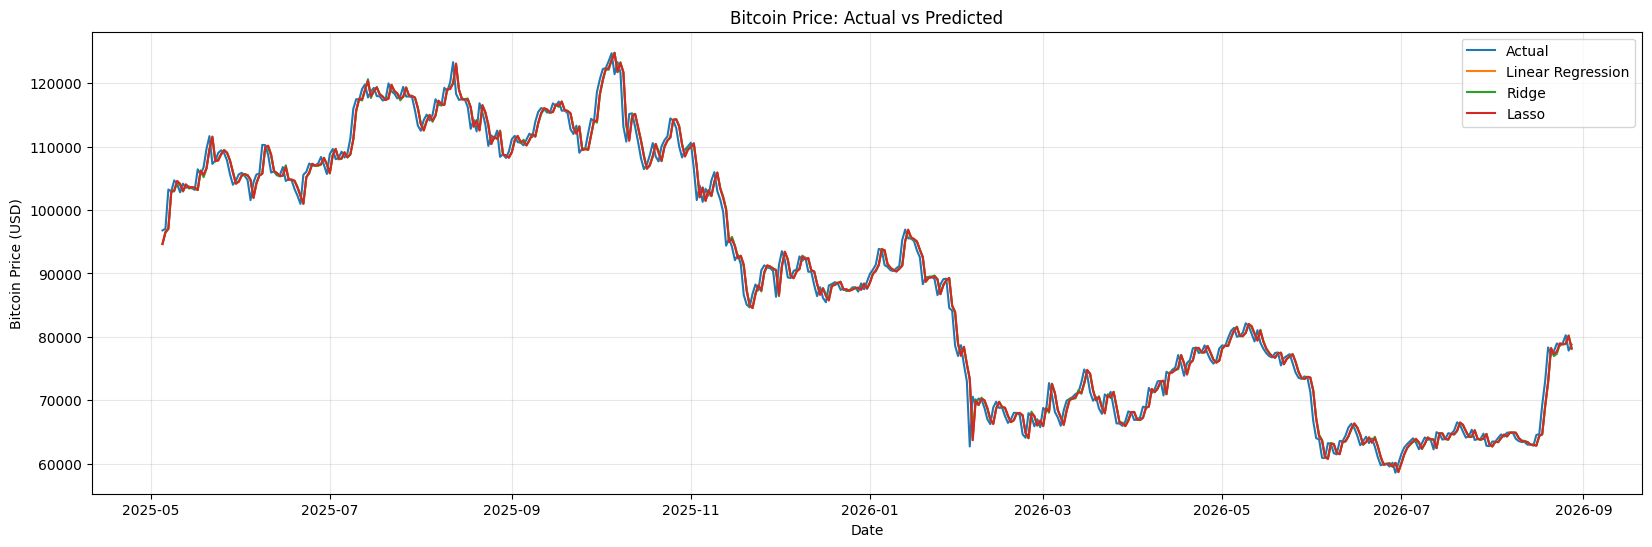

In [42]:
plt.figure(figsize=(20, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual"
)

plt.plot(
    y_test.index,
    linear_pred,
    label="Linear Regression"
)

plt.plot(
    y_test.index,
    ridge_pred,
    label="Ridge"
)

plt.plot(
    y_test.index,
    lasso_pred,
    label="Lasso"
)

plt.title("Bitcoin Price: Actual vs Predicted")

plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [43]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Linear": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

coefficients

,Feature,Linear,Ridge,Lasso
0,Open,15750.736847,6924.506702,22373.947523
1,High,2109.759277,4822.743131,3590.105587
2,Low,2198.287191,5026.315267,180.177633
3,Volume,42.230213,45.371360,40.902010
4,Previous_Close,4669.677306,6896.417917,-1333.585786
5,Return_1D,47.639582,52.160273,44.855230
6,MA_7,-301.998459,841.835177,-298.263959
7,MA_30,-40.686111,-145.960064,-49.748663
8,Volatility_7,-31.486435,-34.575815,-30.409578
9,High_Low_Range,36.407864,65.850952,-86.841062


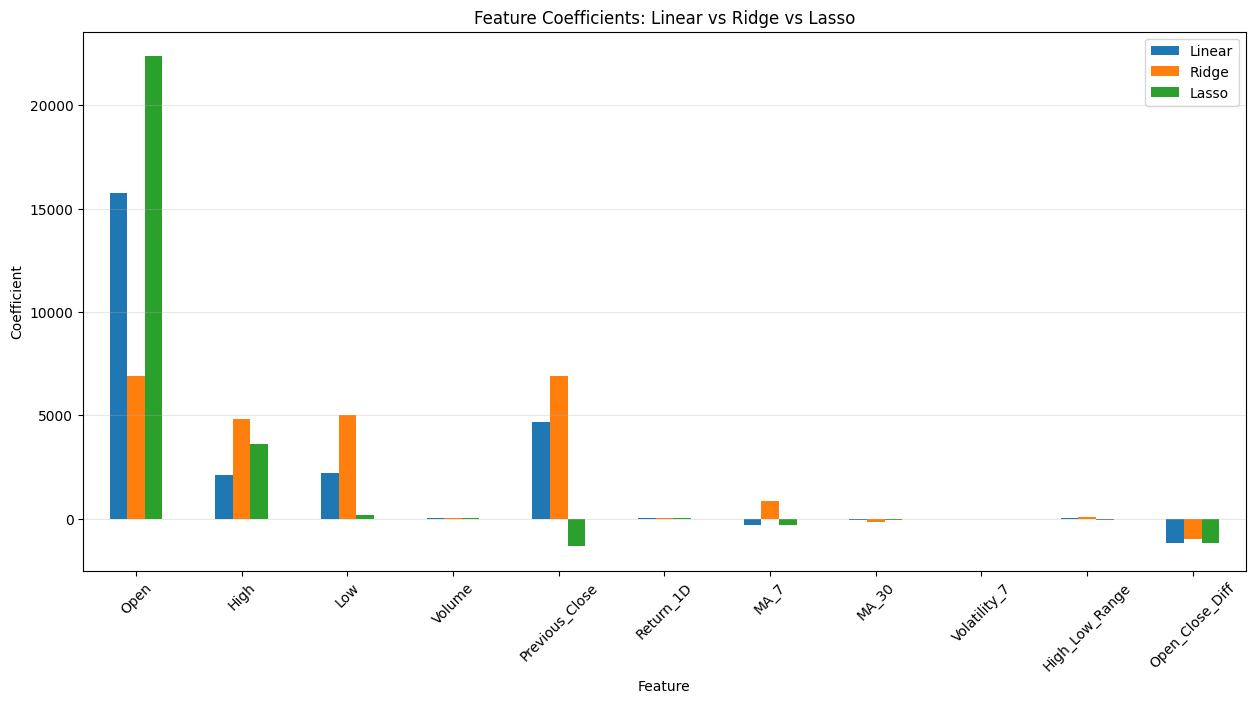

In [44]:
coefficients.set_index("Feature").plot(
    kind="bar",
    figsize=(15, 7)
)

plt.title("Feature Coefficients: Linear vs Ridge vs Lasso")

plt.ylabel("Coefficient")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

## Conclusion

In this project, Linear Regression, Ridge Regression, and Lasso Regression were compared for next-day Bitcoin price prediction.

The dataset was split chronologically to preserve the time-series structure and avoid using future observations during model training.

Several features were engineered from historical Bitcoin market data, including moving averages, daily returns, volatility, and previous closing prices.

The models were evaluated using:

- MAE
- RMSE
- MSE

Ridge and Lasso regression introduce regularization, which can help control model complexity and reduce the influence of highly correlated features.

This project is intended as an educational demonstration of regression and regularization techniques on real-world financial time-series data and should not be considered a trading strategy or financial advice.